Breast Cancer Detection Project
Steps to take:

Phase 1: Data and EDA

Get the data
EDA first - Check and Analyse
Feature Transformation:
Standardization, Scale, or PCA
Feature Selection
Train test split
Phase 2: Model Building

Modelling
Testing
Phase 3: Deployment

Export the model
Check for important features
--

We write a function that takes those important values (4 top important ones), and makes a prediction on those, and returns the prediction
We will deploy the model on Gradio on Hugging Face
We will learn deployment with Streamlit as well

In [ ]:
! 1

import numpy as np # ok
import pandas as pd #ok
import matplotlib.pyplot as plt # ok
import seaborn as sns # ok

from sklearn.datasets import load_breast_cancer #ok
from sklearn.model_selection import train_test_split # ok

from sklearn.tree import DecisionTreeClassifier, plot_tree # ok
from sklearn.ensemble import RandomForestClassifier # ok

# classification evaluation metrics are needed here
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # ok


In [ ]:
# 2
# Data Acquired during the imports only
# let's build the entire dataframe first
df = pd.DataFrame(load_breast_cancer().data, columns =load_breast_cancer().feature_names)

df['target'] = load_breast_cancer().target

# if we want actual labels in the dataset
# df['target'] = df['target'].map({0 : 'Malignant', 1: 'Benign'})


# EDA
df.head()

df.shape

df.isnull().sum()

df.describe()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [22]:
import pandas as pd
print(pd.__version__)

3.0.3


In [10]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum().sum())
print(corr_matrix.shape)
print(corr_matrix.head())

(569, 31)
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symm

Let's find the most important features and use them only for this project
we are checking the correlation matrix
each feature will be compared with other features
whichever features have high correlation values, will be kept
or the other way is, to check correlation ONLY with the Target Column

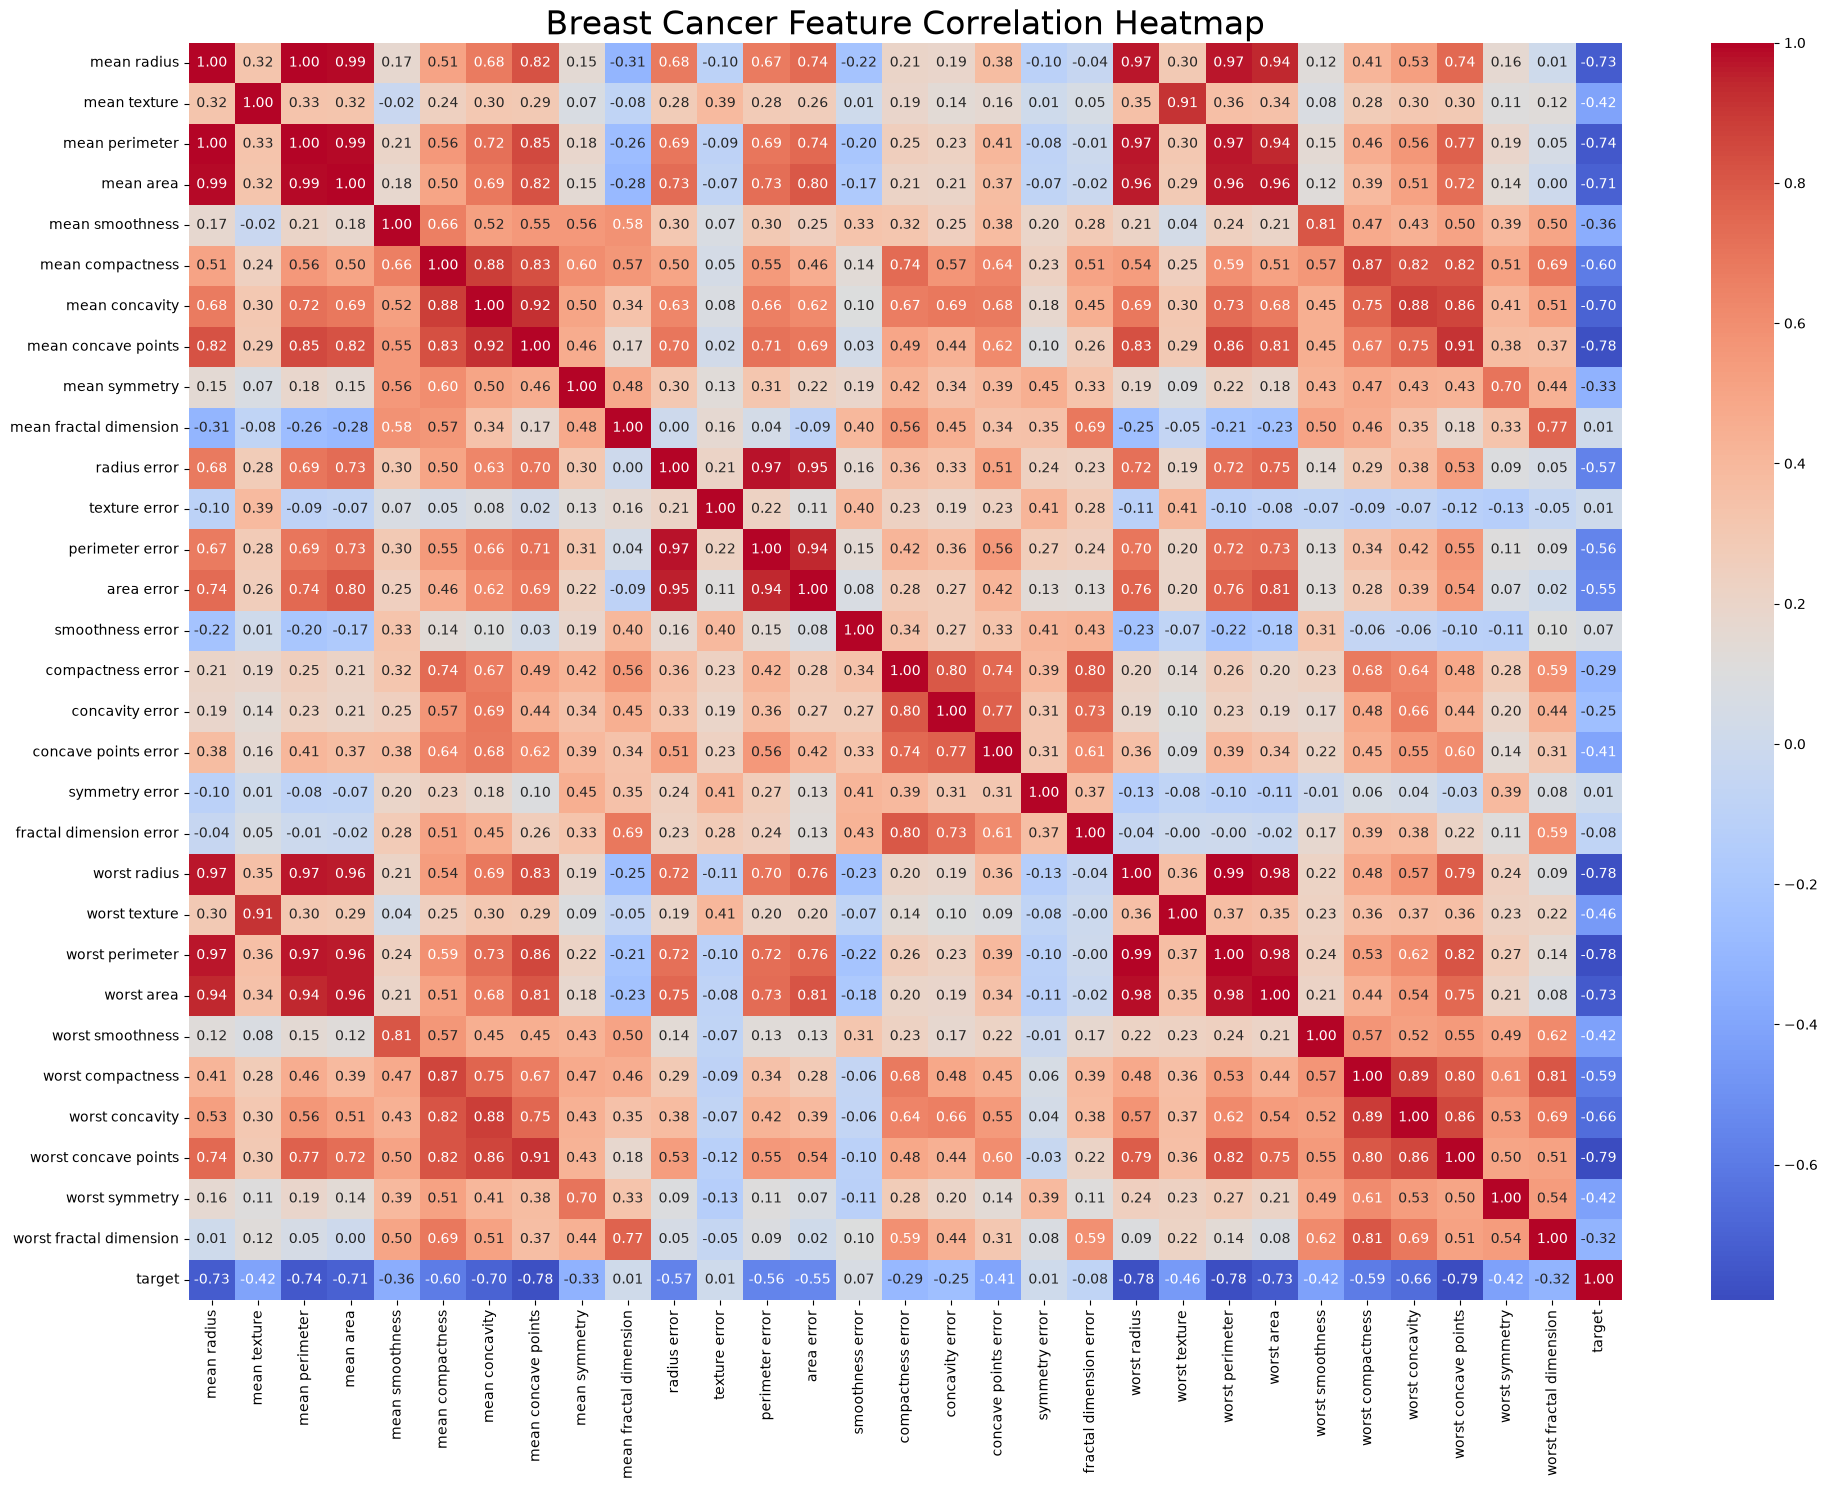

In [11]:
# 3 

# Using correlation between the columns
# take 90% & above
corr_matrix = df.corr()

# Correlation
plt.figure(figsize= (20, 15))
sns.heatmap(df.corr(), annot= True, cmap = 'coolwarm', fmt = ".2f")
plt.title("Breast Cancer Feature Correlation Heatmap", fontsize = 24)
plt.tight_layout()
plt.show()


In [18]:
# 4 check Linda

corr_matrix = df.corr(numeric_only=True)

for i in range(len(corr_matrix)):
    corr_matrix.iat[i, i] = 0

threshold = 0.9

high_corr_cols = [
    col for col in corr_matrix.columns
    if corr_matrix[col].max() > threshold
]

print(len(high_corr_cols))
print(high_corr_cols)

14
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'radius error', 'perimeter error', 'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concave points']


In [17]:
# 4 check Linda

corr_matrix = df.corr(numeric_only=True)

arr = corr_matrix.to_numpy(copy=True)
np.fill_diagonal(arr, 0)

corr_matrix.iloc[:, :] = arr

threshold = 0.9

high_corr_cols = [col for col in corr_matrix.columns if corr_matrix[col].max() > threshold]

print(len(high_corr_cols))
print(high_corr_cols)

14
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'radius error', 'perimeter error', 'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concave points']


In [12]:
# 4

# Selecting columns only with high correlation
corr_matrix = df.corr()
np.fill_diagonal(corr_matrix.values, 0) # fill the diagonal with 0 instead of 1
 
threshold = 0.9
# use the list comprehension with expression
high_corr_cols = [col for col in corr_matrix.columns if corr_matrix[col].max() > threshold]
print(len(high_corr_cols))
print(high_corr_cols)

ValueError: underlying array is read-only

In [ ]:
# 5 
# We can also, ONLY KEEP COLUMNs with high correlation with the target
 
corr_matrix = df.corr()['target'].abs()
corr_matrix['target'] = 0
 
threshold = 0.6
# use the list comprehension with expression
high_corr_target_cols = corr_matrix[corr_matrix > threshold]
 
print(len(high_corr_target_cols))
print(high_corr_target_cols)

10
mean radius             0.730029
mean perimeter          0.742636
mean area               0.708984
mean concavity          0.696360
mean concave points     0.776614
worst radius            0.776454
worst perimeter         0.782914
worst area              0.733825
worst concavity         0.659610
worst concave points    0.793566
Name: target, dtype: float64


In [6]:
# 6

# Feature Selection - already done by sklearn
X = load_breast_cancer().data
 
y = load_breast_cancer().target
# malignant or Benign
# Cancer - moving around cancer cell === Benign means local and dead
 
# train test split -
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size= 0.2,
                                                    random_state = 42,
                                                    #stratify = y # homework for today
                                                    )
 

In [7]:
# 7 
# Random Forest Classifier
model_rf_clf = RandomForestClassifier(
    n_estimators = 10,
    random_state= 42
)
 
model_rf_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [8]:
# 8 

print("="*15, "Model Testing", "="*15)
 
# Predictions for Random Forest
y_pred_test_rf = model_rf_clf.predict(X_test) # unseen data
y_pred_train_rf = model_rf_clf.predict(X_train) # model has seeen these inputs
 
# Evaluation of the model
test_acc_rf = accuracy_score(y_test, y_pred_test_rf) # Testing accuracy
train_acc_rf = accuracy_score(y_train, y_pred_train_rf) #  Training accuracy
 
print("====== Random Forest Evaluation ======")
print(f"Testing Accuracy: {test_acc_rf*100:.2f}%")
print(f"Training Accuracy: {train_acc_rf*100:.2f}%")
 

=============== Model Testing ===============
====== Random Forest Evaluation ======
Testing Accuracy: 95.61%
Training Accuracy: 99.78%


In [9]:
# 9 

importances = model_rf_clf.feature_importances_
feature_names = load_breast_cancer().feature_names
 
df_feature_importance = pd.DataFrame({
    'features': feature_names,
    'importance': importances
})
 
df_top_features = df_feature_importance.sort_values(by= 'importance', ascending = False)
top_features = df_top_features.head(15)['features'].reset_index(drop = True)
top_features
 
 

0     worst concave points
1      mean concave points
2               worst area
3             worst radius
4              mean radius
5               area error
6             radius error
7           mean perimeter
8        worst compactness
9          worst perimeter
10         worst concavity
11           worst texture
12         concavity error
13               mean area
14         mean smoothness
Name: features, dtype: str

In [ ]:
# 10

# Feature Selection - already done by sklearn
X = df[list(top_features)] # training set only has the top features columns
y = load_breast_cancer().target
 
# train test split -
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size= 0.2,
                                                    random_state = 42,
                                                    #stratify = y # homework for today
                                                    )
 

In [ ]:
# 11



In [19]:

# Selecting columns only with high correlation
# corr_matrix = df.corr() OR
corr_matrix = df.corr(numeric_only=True)

np.fill_diagonal(corr_matrix.values, 0) # fill the diagonal with 0 instead of 1

threshold = 0.9
# use the list comprehension with expression
high_corr_cols = [col for col in corr_matrix.columns if corr_matrix[col].max() > threshold]
print(len(high_corr_cols))
print(high_corr_cols)

ValueError: underlying array is read-only

In [ ]:
# We can also, ONLY KEEP COLUMNs with high correlation with the target

corr_matrix = df.corr()['target']
corr_matrix['target'] = 0

threshold = 0.7

# use the list comprehension with expression
# high_corr_target_cols = [col for col in corr_matrix.columns if corr_matrix[col].max() > threshold] # error for my coding but not the others
# high_corr_target_cols = [col for col in corr_matrix.index if abs(corr_matrix[col]) > threshold]
# high_corr_target_cols = corr_matrix > threshold]

print(len(high_corr_target_cols))
print(high_corr_target_cols)

8
['mean radius', 'mean perimeter', 'mean area', 'mean concave points', 'worst radius', 'worst perimeter', 'worst area', 'worst concave points']


In [2]:
top_features = corr_matrix.index
print(list(top_features))

NameError: name 'corr_matrix' is not defined

In [ ]:
# Finding important feature by using 3 methods
# i. 

In [ ]:
importance = model_rf_clf.feature_importances_


rf = RandomForestClassifier(random_state=42)
rf.fit(X_scaled, y)
importance = pd.DataFrame({"Feature": X.columns,"Importance": rf.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)
importance.head(5)


In [ ]:
# Feature selection
# initially we will keep all the features
# we will run the random forest & get a list 



In [33]:
corr_matrix = df.corr()['target']

#corr_matrix.columns

In [12]:
load_breast_cancer()

print(load_breast_cancer().(DESC))
#print(df["target"].value_counts())
#0 = Malignant -212
#1 = Benign - 357

SyntaxError: invalid syntax (331908564.py, line 3)